# Composite vector space tutorial

In romtools, a composite vector space refers to multiple vector spaces that are stichted together into one vector space. 
The use case of a composite vector space is if you want to have independent basis functions for different DOFs (e.g., mass, momentum)
In this tutorial you will learn:
- How to construct a composite vector space that comprises several vector spaces stiched together



In [1]:
#First, let's import the relavant modules:
import romtools
import numpy as np
from matplotlib import pyplot as plt
from romtools import vector_space, composite_vector_space

In [2]:
#Now, we will load in snapshots from a FOM. Here, we use pre-computed snapshots of the 1D Euler equations obtained using pressio-demo-apps
snapshots = np.load('snapshots.npz')['snapshots']

## The snapshots are in tensor form:
n_vars, nx, nt = snapshots.shape

# Along the first axis we have snapshots of mass (rho), momentum (rho U), and energy (rho E), respectively

## Note that romtools works with tensor forms (https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space.html)

In [3]:
# In this example, we make a composite vector space where each state variable in our snapshot matrix has each own basis
# (This is often times referred to as "vector POD" in the literature

#Like the last tuorial, let's use a truncater that controls for how we want to truncate our basis.
my_truncater = vector_space.utils.EnergyBasedTruncater(0.999)

In [4]:
#Now, let's construct a vector space using POD for the DENSITY VARIABLE ONLY
my_vector_space_rho = vector_space.VectorSpaceFromPOD(snapshots[0:1],truncater=my_truncater)

#Let's look a the shape of our vector space:
print('The vector space for rho is of shape: ', my_vector_space_rho.extents())

The vector space for rho is of shape:  (1, 500, 4)


In [5]:
# Now, we will make vector spaces for the next two variables (momentum and energy)
my_vector_space_rhoU = vector_space.VectorSpaceFromPOD(snapshots[1:2],truncater=my_truncater)
print('The vector space for rhoU is of shape: ', my_vector_space_rhoU.extents())
my_vector_space_rhoE = vector_space.VectorSpaceFromPOD(snapshots[2:3],truncater=my_truncater)
print('The vector space for rhoE is of shape: ', my_vector_space_rhoE.extents())

The vector space for rhoU is of shape:  (1, 500, 31)
The vector space for rhoE is of shape:  (1, 500, 6)


In [6]:
# Now we will create a composite vector space that stiches these three vector spaces together:
my_composite_vector_space = composite_vector_space.CompositeVectorSpace([my_vector_space_rho,my_vector_space_rhoU,my_vector_space_rhoE])

# Let's look at the size of this vector space:
print('The composite vector space is of shape: ' , my_composite_vector_space.extents())
#We see that the number of basis vectors is the sum of the individual vector spaces

The composite vector space is of shape:  [  3 500  41]


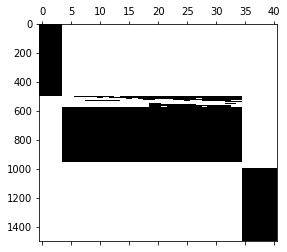

In [7]:
#Let's view the sparsity pattern if we view this as a tradititional basis matrix
#First, let's grab the basis
composite_basis = my_composite_vector_space.get_basis()
#Now we will reshape it into a matrix. Note all of romtools uses order 'C' for reshaping
basis_matrix = np.reshape(composite_basis,(composite_basis.shape[0]*composite_basis.shape[1],composite_basis.shape[2]),'C')

plt.spy(basis_matrix)
plt.gca().set_aspect(0.025)
plt.show()

In [8]:
# We see the basis has a block structure. This means that each state variable will effectively have their own reduced coordinates.